# Dataset 3 — Exploratory Analysis & Cleaning

**Goal:** Produce three clean output files from the raw dataset3:
- `dataset3_cleaned.csv` — valid measurement rows ready for analysis
- `dataset3_removed.csv` — rows removed with documented reason
- `dataset3_derived_quantities.csv` — Finnish derived quantities set aside separately

**Pipeline:**
1. Load raw data
2. Parse result and uncertainty columns
3. Clean nuclide names (canonical mapping, categorisation)
4. Standardise units
5. Exploratory analysis (distributions, outliers, MDA, sample structure)
6. Apply STUK-confirmed removals
7. Export outputs

---
## Step 1 — Load Raw Data

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Load
d3 = pd.read_csv('dataset3.csv', usecols=[0, 1, 2, 3, 4])

# Clean column names
d3.columns = (
    d3.columns.astype(str)
    .str.strip()
    .str.lower()
    .str.replace(' ', '', regex=False)
)

print("Cleaned raw columns:")
print(d3.columns.tolist())

# Build a robust rename map
rename_map = {}

for c in d3.columns:
    if 'pseudo' in c and 'id' in c:
        rename_map[c] = 'pseudoid'
    elif 'nuclide' in c:
        rename_map[c] = 'nuclide'
    elif 'result' in c and 'uncert' not in c:
        rename_map[c] = 'result_raw'
    elif 'uncertainty' in c:
        rename_map[c] = 'uncertainty_pct'
    elif 'quantumunit' in c or c == 'unit':
        rename_map[c] = 'quantumunit'
    elif c == 'mda':
        rename_map[c] = 'mda'

d3 = d3.rename(columns=rename_map)

print("\nColumns after rename:")
print(d3.columns.tolist())

# Safety check
required = ['pseudoid', 'nuclide', 'result_raw', 'uncertainty_pct', 'quantumunit']
missing = [c for c in required if c not in d3.columns]
print("\nMissing required columns:", missing)

Cleaned raw columns:
['pseudoid', 'nuclide', 'result', 'unit', 'uncertainty']

Columns after rename:
['pseudoid', 'nuclide', 'result_raw', 'quantumunit', 'uncertainty_pct']

Missing required columns: []


---
## Step 2 — Parse Result and Uncertainty

The result column contains either a numeric value or a value prefixed with `<`
indicating the measurement was below the minimum detectable activity (MDA).
We parse both cases and flag MDA rows separately.

In [78]:
# MDA flag: result starts with '<'
d3['is_mda'] = d3['result_raw'].astype(str).str.startswith('<')

# Result: strip '<' prefix and convert to float
d3['result'] = pd.to_numeric(
    d3['result_raw'].astype(str).str.lstrip('<').str.strip(),
    errors='coerce'
)

# Uncertainty: strip '%' and convert to float
d3['uncertainty'] = pd.to_numeric(
    d3['uncertainty_pct'].astype(str)
      .str.replace('%', '', regex=False).str.strip(),
    errors='coerce'
)

print(f'Total rows          : {len(d3):,}')
print(f'Unique samples      : {d3["pseudoid"].nunique():,}')
print(f'Unique nuclide names: {d3["nuclide"].nunique():,}')
print(f'MDA rows            : {d3["is_mda"].sum():,}  ({d3["is_mda"].mean():.1%})')
print(f'Null results        : {d3["result"].isna().sum():,}')
print()
d3[['result', 'uncertainty']].describe()

Total rows          : 98,096
Unique samples      : 23,162
Unique nuclide names: 375
MDA rows            : 37,774  (38.5%)
Null results        : 36



,result,uncertainty
count,9.806000e+04,6.208400e+04
mean,4.530591e+50,5.942511e+14
std,1.243201e+53,7.403198e+16
min,-2.499301e+30,-7.520000e+02
25%,2.628092e-03,5.300000e+00
50%,6.897975e-01,7.100000e+00
75%,3.799046e+01,1.100000e+01
max,3.877190e+55,9.223372e+18


---
## Step 3 — Clean Nuclide Names

The raw nuclide column contains 383 unique strings but many are duplicates
due to inconsistent capitalisation, missing hyphens, typos, Finnish-language
derived quantities, ambiguous element symbols, and garbage entries.

**Three-step approach:**
- **Step A:** Strip whitespace (done in Step 1)
- **Step B:** Apply canonical name mapping (e.g. `cs-137` -> `Cs-137`)
- **Step C:** Classify each row into `clean`, `derived_quantity`, or `garbage`

**STUK answers applied:**
- Q6: `Ra-266` and `Ra-238` are typos for `Ra-226` and `Ra-228` — corrected in canonical map
- Q4: Finnish derived quantities confirmed as separate measurement types — set aside
- Q5 (red): `Th`, `U`, `Rn`, `Sr`, `Ra` (element symbols without mass number) — confirmed removals
- Q14: `T` entry confirmed as entry error — removed

In [79]:
# ── Step B: canonical name mapping ───────────────────────────────────────────
canonical_map = {
    # Capitalisation fixes
    'cs-137':  'Cs-137',
    'u-238':   'U-238',
    # Missing hyphen fixes
    'U238':    'U-238',
    'Ra226':   'Ra-226',
    'Pb210':   'Pb-210',
    'U234':    'U-234',
    'Th228':   'Th-228',
    'Cm244':   'Cm-244',
    # All-caps fixes
    'TH-232':  'Th-232',
    'TH-230':  'Th-230',
    'SR-90':   'Sr-90',
    # Punctuation fixes
    'Ra.228':  'Ra-228',
    # Isomer notation
    'Sb-134b': 'Sb-134',
    # Q6 (STUK confirmed): typo corrections
    'Ra-266':  'Ra-226',
    'Ra-238':  'Ra-228',
}
d3['nuclide_clean'] = d3['nuclide'].replace(canonical_map)

# ── Step C: classify rows ─────────────────────────────────────────────────────

# Q4 (STUK): Finnish derived/summary quantities — not nuclide measurements
derived = [
    'Kokonaisalfa', 'Kokonaisbeeta', 'Viitteellinen annos',
    'alfa', 'Kok-alfa', 'Kokonaisalfab', 'Kok-beeta',
    'Sr stab.', 'Sr stab', 'Sr. stab.', 'Sr saalis',
    'Uraani', 'U238 arvio', 'Uraani ja Po yht', 'U-238 (massa)',
]

# Q5 + Q14 (STUK confirmed removals): element symbols without mass number,
# unidentifiable entries, and confirmed entry errors
garbage = ['27827C', 'Th', 'TH', 'U', 'Rn', 'Sr', 'Ra', 'T', 'v', 'u']

d3['nuclide_category'] = 'clean'
d3.loc[d3['nuclide_clean'].isin(derived),  'nuclide_category'] = 'derived_quantity'
d3.loc[d3['nuclide_clean'].isin(garbage),  'nuclide_category'] = 'garbage'

# ── Summary ───────────────────────────────────────────────────────────────────
print('=== ROW COUNTS BY CATEGORY ===')
print(d3['nuclide_category'].value_counts().to_string())
print()
print(f'Unique clean nuclide names : {d3[d3["nuclide_category"]=="clean"]["nuclide_clean"].nunique()}')
print()
print('=== CANONICAL MERGES APPLIED ===')
for orig, canon in canonical_map.items():
    n = (d3['nuclide'] == orig).sum()
    if n:
        print(f'  {orig!r:15s} -> {canon!r}  ({n} rows merged)')
print()
print('=== DERIVED QUANTITIES (set aside, not dropped) ===')
print(d3[d3['nuclide_category']=='derived_quantity']['nuclide_clean']
      .value_counts().to_string())
print()
print('=== GARBAGE (excluded) ===')
print(d3[d3['nuclide_category']=='garbage'][['pseudoid','nuclide']]
      .value_counts().reset_index().to_string(index=False))

=== ROW COUNTS BY CATEGORY ===
nuclide_category
clean      98063
garbage       33

Unique clean nuclide names : 369

=== CANONICAL MERGES APPLIED ===
  'U238'          -> 'U-238'  (1 rows merged)
  'U234'          -> 'U-234'  (2 rows merged)
  'TH-232'        -> 'Th-232'  (951 rows merged)
  'TH-230'        -> 'Th-230'  (33 rows merged)
  'SR-90'         -> 'Sr-90'  (1706 rows merged)

=== DERIVED QUANTITIES (set aside, not dropped) ===
Series([], )

=== GARBAGE (excluded) ===
 pseudoid nuclide  count
    51098      TH      1
    66652      TH      1
    77603      TH      1
    76623       U      1
    76623      TH      1
    76161       U      1
    76161      TH      1
    75747       U      1
    75747      TH      1
    75396       U      1
    75396      TH      1
    73362       T      1
    72711       U      1
    72711      TH      1
    70366       U      1
    70366      TH      1
    65756      TH      1
    51098       U      1
    65458      TH      1
    64260       U 

---
## Step 4 — Standardise Units

The unit column has 249 unique strings. Problems identified and resolved:

| Problem | Resolution |
|---|---|
| Formatting variants (`Bq/m^3` vs `Bq/m3`) | Renamed to canonical form |
| mBq, MicroBq, kBq scale variants | Converted to base Bq numerically |
| `Bq/g` | Converted to `Bq/kg` (multiply by 1000) |
| H-3 in kBq/l and TU | Converted to Bq/l |
| `Bq/_`, `Bq/laaduton`, `Bq/nayte` | Renamed to `Bq/sample` (Q8: per-sample results) |
| `Bq/jotain[...]` | Flagged as ANOMALY (Q8: missing source data — to be removed) |
| `Bq/kg_kp`, `Bq/kg_tp`, `Bq/kg_tu`, `Bq/kg_np` | Kept separate — Q12/Q13: NOT equivalent |
| `mg/kg`, `ug/l` for U-238/Th-232 | Flagged as `is_mass_concentration` — Q10: different measurement type |
| Pu-239 column shift | Flagged as `is_pu239_240` — Q7: Pu-239+240 combined measurement |

In [80]:
# ── Rename formatting variants ────────────────────────────────────────────────
unit_map = {
    # Bq/kg dry weight variants (Q9: kp = kuivapaino = dry weight)
    'Bq/kg kp':    'Bq/kg_kp',
    'Bq/kg-kp':    'Bq/kg_kp',
    'Bq/kg k.p.':  'Bq/kg_kp',
    'Bq/kg kp.':   'Bq/kg_kp',
    'Bq/kg. k.p.': 'Bq/kg_kp',
    'Ba/kg kp':    'Bq/kg_kp',
    'Bq/kg dw':    'Bq/kg_kp',
    # Bq/kg fresh weight variants (Q9: tp = tuorepaino = fresh weight)
    'Bq/kg tp':    'Bq/kg_tp',
    'Bq/kg tp.':   'Bq/kg_tp',
    'Bq/kg t.p.':  'Bq/kg_tp',
    # Other weight bases (Q9: tu = tuhka = ash, np = neste = liquid)
    'Bq/kg tuhka': 'Bq/kg_tu',
    'Bq/kg nes.':  'Bq/kg_np',
    # Volume units
    'Bq/m^3':      'Bq/m3',
    'Bq/m^2':      'Bq/m2',
    'Bq/litra':    'Bq/l',
    'Bq/L':        'Bq/l',
    # Typos
    'Bg/kg':       'Bq/kg',
    'bq':          'Bq',
    # Per-sample results (Q8/Q9: laaduton/_ means result is for the whole sample)
    'Bq/laaduton': 'Bq/sample',
    'Bq/_':        'Bq/sample',
    'Bq/nayte':    'Bq/sample',
    'Bq/näyte':    'Bq/sample',
    'mBq/näyte':   'mBq/sample',
    # Anomaly — missing source data confirmed by STUK
    'Bq/jotain[tarkista puuttuvat lähtotiedot!]': 'ANOMALY',
}
d3['unit_std'] = d3['quantumunit'].replace(unit_map)

# ── Numeric conversions: same physical quantity, different scale ──────────────

# H-3: kBq/l -> Bq/l, TU -> Bq/l (1 TU = 0.118 Bq/l)
h3 = d3['nuclide_clean'] == 'H-3'
d3.loc[h3 & (d3['unit_std'] == 'kBq/l'), 'result'] *= 1000
d3.loc[h3 & (d3['unit_std'] == 'kBq/l'), 'unit_std'] = 'Bq/l'
d3.loc[h3 & (d3['unit_std'] == 'TU'),    'result'] *= 0.118
d3.loc[h3 & (d3['unit_std'] == 'TU'),    'unit_std'] = 'Bq/l'

# mBq -> Bq (divide by 1,000)
for mbq, bq in {'mBq/l':'Bq/l', 'mBq/kg':'Bq/kg',
                'mBq/m3':'Bq/m3', 'mBq/g':'Bq/g'}.items():
    mask = d3['unit_std'] == mbq
    d3.loc[mask, 'result'] /= 1000
    d3.loc[mask, 'unit_std'] = bq

# MicroBq -> Bq (divide by 1,000,000)
for u in ['MicroBq/m3', 'µBq/m3', 'µBq/m^3']:
    mask = d3['unit_std'] == u
    d3.loc[mask, 'result'] /= 1_000_000
    d3.loc[mask, 'unit_std'] = 'Bq/m3'

# Bq/g -> Bq/kg (multiply by 1,000)
mask = d3['unit_std'] == 'Bq/g'
d3.loc[mask, 'result'] *= 1000
d3.loc[mask, 'unit_std'] = 'Bq/kg'

# ── Flag special row types ────────────────────────────────────────────────────

# Q10: mass concentration rows (U-238/Th-232 from mass spectrometry)
# Different physical quantity from Bq — kept but flagged, not mixed with activity
mass_units = ['mg/kg', 'µg/l', 'µg/kg', 'µg/kg kp',
              'mikrog/l', '?g/l', 'mg/kg kp', 'mg']
d3['is_mass_concentration'] = d3['unit_std'].isin(mass_units)

# Q7: Pu-239+240 combined rows — result column holds '240' (mass number),
# actual activity value is in the unit column
d3['is_pu239_240'] = (
    (d3['nuclide_clean'] == 'Pu-239') &
    (d3['result_raw'].astype(str).str.strip() == '240')
)

# ── Summary ───────────────────────────────────────────────────────────────────
print(f'Unique units before : {d3["quantumunit"].nunique()}')
print(f'Unique units after  : {d3["unit_std"].nunique()}')
print()
print('=== FINAL UNIT COUNTS (top 20) ===')
print(d3['unit_std'].value_counts().head(20).to_string())
print()
print(f'Mass concentration rows flagged (Q10) : {d3["is_mass_concentration"].sum()}')
print(f'Pu-239+240 combined rows flagged (Q7) : {d3["is_pu239_240"].sum()}')

Unique units before : 71
Unique units after  : 41

=== FINAL UNIT COUNTS (top 20) ===
unit_std
Bq/m3          32026
Bq/kg_kp       25247
Bq/kg          19336
Bq/l            6857
Bq/m2           4974
Bq/kg_tp        4577
mSv/vuosi       1183
Bq/sample        903
Bq               588
mg/kg            333
mg/g tuhkaa      293
mg/l             241
µg/l             208
mg/g kuivaa      132
Bq/kg_np         125
mikrog/l          27
mBq/sample        27
ug                27
ANOMALY           23
µg/kg kp          18

Mass concentration rows flagged (Q10) : 625
Pu-239+240 combined rows flagged (Q7) : 0


---
## Step 5 — Exploratory Analysis

Performed on clean rows only, before applying STUK-confirmed removals.

In [81]:
# Working subset for EDA: clean nuclide category only
eda_df = d3[d3['nuclide_category'] == 'clean'].copy()
print(f'EDA dataset: {len(eda_df):,} rows, '
      f'{eda_df["pseudoid"].nunique():,} samples, '
      f'{eda_df["nuclide_clean"].nunique()} unique nuclides')

EDA dataset: 98,063 rows, 23,162 samples, 369 unique nuclides


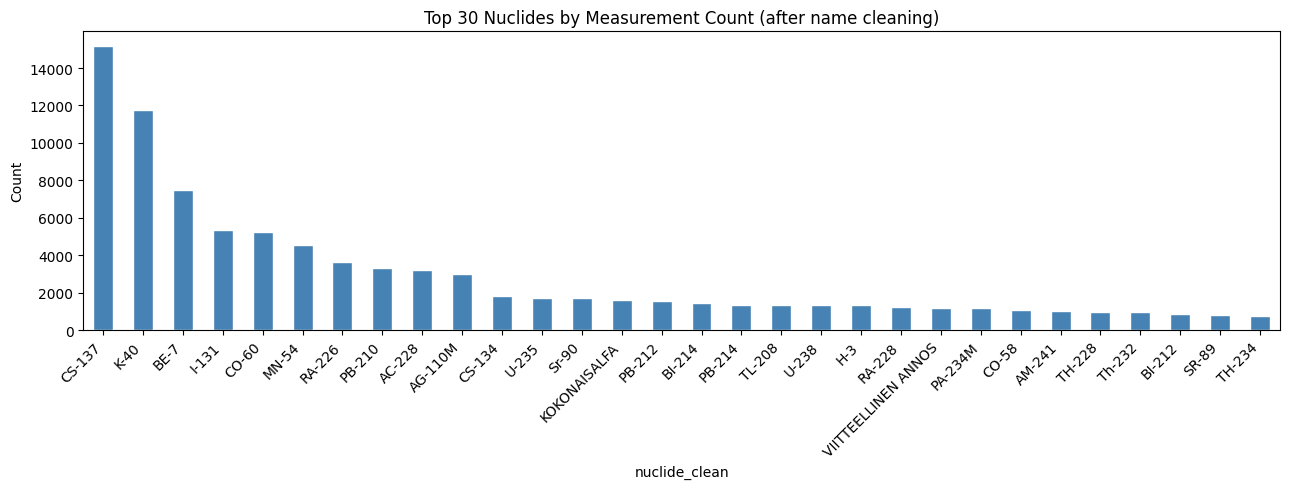

nuclide_clean
CS-137                 15199
K-40                   11769
BE-7                    7468
I-131                   5324
CO-60                   5259
MN-54                   4525
RA-226                  3656
PB-210                  3330
AC-228                  3218
AG-110M                 3000
CS-134                  1842
U-235                   1710
Sr-90                   1706
KOKONAISALFA            1582
PB-212                  1531
BI-214                  1468
PB-214                  1351
TL-208                  1343
U-238                   1338
H-3                     1335
RA-228                  1225
VIITTEELLINEN ANNOS     1204
PA-234M                 1182
CO-58                   1051
AM-241                  1012
TH-228                   980
Th-232                   951
BI-212                   856
SR-89                    780
TH-234                   741


In [82]:
# ── Top 30 nuclides by measurement count ─────────────────────────────────────
top30 = eda_df['nuclide_clean'].value_counts().head(30)
top20 = top30.head(20).index

fig, ax = plt.subplots(figsize=(13, 5))
top30.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Top 30 Nuclides by Measurement Count (after name cleaning)')
ax.set_ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(top30.to_string())

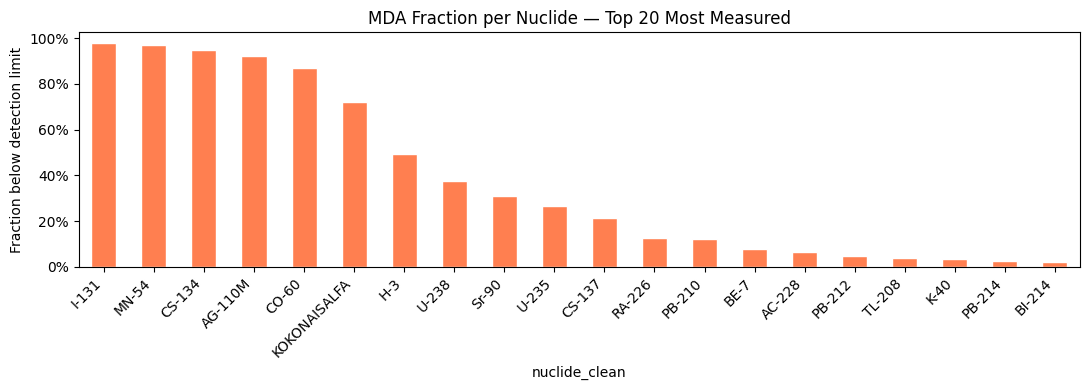

nuclide_clean
I-131           97.7%
MN-54           97.1%
CS-134          94.8%
AG-110M         92.1%
CO-60           87.0%
KOKONAISALFA    71.9%
H-3             49.5%
U-238           37.7%
Sr-90           31.0%
U-235           26.7%
CS-137          21.3%
RA-226          12.7%
PB-210          12.3%
BE-7             8.0%
AC-228           6.6%
PB-212           4.6%
TL-208           3.9%
K-40             3.4%
PB-214           2.6%
BI-214           2.1%


In [83]:
# ── MDA fraction per nuclide (top 20 most measured) ──────────────────────────
mda_frac = (
    eda_df[eda_df['nuclide_clean'].isin(top20)]
    .groupby('nuclide_clean')['is_mda'].mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 4))
mda_frac.plot(kind='bar', ax=ax, color='coral', edgecolor='white')
ax.set_title('MDA Fraction per Nuclide — Top 20 Most Measured')
ax.set_ylabel('Fraction below detection limit')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(mda_frac.map('{:.1%}'.format).to_string())

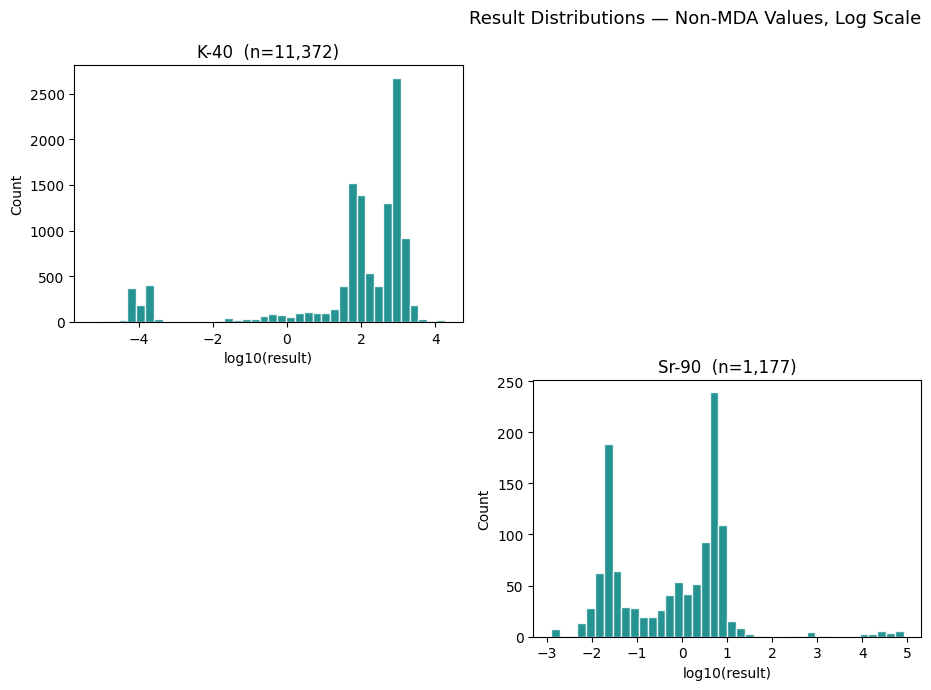

In [84]:
# ── Result distributions for key nuclides (log scale, non-MDA only) ──────────
key_nuclides = ['K-40', 'Cs-137', 'Pb-210', 'Ra-226', 'Sr-90', 'Be-7']

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, nuc in zip(axes.flat, key_nuclides):
    vals = eda_df[(eda_df['nuclide_clean'] == nuc) &
                  (~eda_df['is_mda'])]['result'].dropna()
    vals = vals[vals > 0]
    if len(vals) == 0:
        ax.set_visible(False)
        continue
    ax.hist(np.log10(vals), bins=40, color='teal', edgecolor='white', alpha=0.85)
    ax.set_title(f'{nuc}  (n={len(vals):,})')
    ax.set_xlabel('log10(result)')
    ax.set_ylabel('Count')
fig.suptitle('Result Distributions — Non-MDA Values, Log Scale', fontsize=13)
plt.tight_layout()
plt.show()

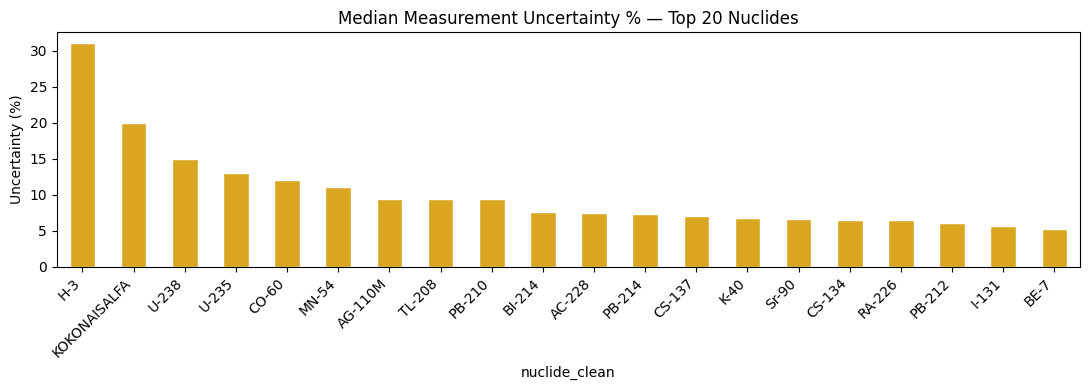

nuclide_clean
H-3             31.0
KOKONAISALFA    20.0
U-238           15.0
U-235           13.0
CO-60           12.0
MN-54           11.0
AG-110M          9.4
TL-208           9.4
PB-210           9.4
BI-214           7.6
AC-228           7.4
PB-214           7.3
CS-137           7.1
K-40             6.8
Sr-90            6.6
CS-134           6.6
RA-226           6.5
PB-212           6.0
I-131            5.7
BE-7             5.3


In [85]:
# ── Median uncertainty per nuclide (top 20) ───────────────────────────────────
unc = (
    eda_df[eda_df['nuclide_clean'].isin(top20)]
    .groupby('nuclide_clean')['uncertainty'].median()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(11, 4))
unc.plot(kind='bar', ax=ax, color='goldenrod', edgecolor='white')
ax.set_title('Median Measurement Uncertainty % — Top 20 Nuclides')
ax.set_ylabel('Uncertainty (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
print(unc.round(1).to_string())

In [86]:
# ── Statistical outlier detection: z-score in log space per nuclide ──────────
# Flags values that are >4 standard deviations from the mean in log scale.
# Note: some of these are confirmed data errors (see Step 6 removals).
from scipy import stats

def z_outliers(group, thresh=4.0):
    vals = group['result'].dropna()
    vals = vals[vals > 0]
    if len(vals) < 10:
        return pd.DataFrame()
    lv = np.log10(vals)
    z  = pd.Series(np.abs(stats.zscore(lv)), index=vals.index)
    return group.loc[z[z > thresh].index]

outlier_df = (
    eda_df[eda_df['nuclide_clean'].isin(top20) & (~eda_df['is_mda'])]
    .groupby('nuclide_clean', group_keys=False)
    .apply(z_outliers)
    .reset_index(drop=True)
)

print(f'Outliers detected (|z| > 4 in log scale): {len(outlier_df)}')
print()
print(outlier_df[['pseudoid', 'nuclide_clean', 'result', 'unit_std', 'uncertainty']]
      .sort_values('result', ascending=False)
      .head(20)
      .to_string(index=False))

Outliers detected (|z| > 4 in log scale): 69

 pseudoid nuclide_clean       result unit_std  uncertainty
    52104        BI-214 1.986573e+33    Bq/m3          4.9
    63639        BI-214 1.333118e+33    Bq/m3          4.3
    52104        PB-214 1.157161e+33    Bq/m3          6.4
    63639        PB-214 9.333570e+32    Bq/m3          5.4
    71339        PB-214 6.369373e+32    Bq/m3          6.6
    59486        PB-214 6.203055e+32    Bq/m3          7.2
    59486        BI-214 5.622615e+32    Bq/m3          8.2
    78342        PB-214 5.476725e+32    Bq/m3          6.7
    57207        BI-214 5.422823e+32    Bq/m3         12.0
    61450        PB-214 4.258928e+32    Bq/m3          7.8
    61450        BI-214 4.068679e+32    Bq/m3          7.9
    57207        PB-214 3.870887e+32    Bq/m3         12.0
    66308        BI-214 3.586317e+32    Bq/m3          8.6
    61049        BI-214 3.352982e+32    Bq/m3          5.6
    66308        PB-214 2.807648e+32    Bq/m3          7.4
    50606 

In [87]:
# ── Sample structure: how many nuclides per sample? ───────────────────────────
nuclides_per_sample = (
    eda_df.groupby('pseudoid')['nuclide_clean']
    .nunique()
    .sort_values(ascending=False)
)

print('=== NUCLIDES PER SAMPLE — DISTRIBUTION ===')
print(nuclides_per_sample.describe().round(2).to_string())
print()

bins   = [0, 1, 2, 3, 5, 10, 20, 50, 100]
labels = ['1', '2', '3', '4-5', '6-10', '11-20', '21-50', '51+']
binned = pd.cut(nuclides_per_sample, bins=bins, labels=labels)
print('=== SAMPLE COUNT BY NUMBER OF NUCLIDES ===')
print(binned.value_counts().sort_index().to_string())
print()

# Most common nuclide combinations in small samples
small = nuclides_per_sample[
    (nuclides_per_sample >= 2) & (nuclides_per_sample <= 4)
].index
combos = (
    eda_df[eda_df['pseudoid'].isin(small)]
    .groupby('pseudoid')['nuclide_clean']
    .apply(lambda x: ', '.join(sorted(x)))
    .value_counts()
    .head(20)
)
print('=== MOST COMMON NUCLIDE COMBINATIONS (2-4 nuclides) ===')
print(combos.to_string())
print()

many = nuclides_per_sample[nuclides_per_sample > 20]
print(f'=== SAMPLES WITH >20 NUCLIDES (n={len(many)}) ===')
print(many.to_string())

=== NUCLIDES PER SAMPLE — DISTRIBUTION ===
count    23162.00
mean         4.16
std          3.74
min          1.00
25%          2.00
50%          3.00
75%          6.00
max         82.00

=== SAMPLE COUNT BY NUMBER OF NUCLIDES ===
nuclide_clean
1        4368
2        6555
3        2667
4-5      3278
6-10     4840
11-20    1398
21-50      54
51+         2

=== MOST COMMON NUCLIDE COMBINATIONS (2-4 nuclides) ===
nuclide_clean
CS-137, K-40                                 3555
CS-134, CS-137                                820
KOKONAISALFA, VIITTEELLINEN ANNOS             718
BE-7, CS-137, K-40                            645
AC-228, K-40, RA-226                          630
AC-228, CS-137, K-40, RA-226                  523
SR-89, Sr-90                                  481
KOKONAISALFA, RN-222, VIITTEELLINEN ANNOS     453
BE-7, CS-137                                  351
CS-134, CS-137, K-40                          211
BE-7, I-131                                   150
CS-137, K-40, RA-226, 

---
## Step 6 — Apply STUK-Confirmed Removals

All removals are based on direct answers from STUK (Q&A document).
Each removed row is tagged with a reason and saved separately.

| Ref | Rows removed | Reason |
|---|---|---|
| Nuclide cleaning | 43 | Garbage nuclide names (`27827C`, `Th`, `U`, `Rn`, `Sr`, `Ra`, `T`, `v`, `u`) |
| Q1 | 4 | Bi-214/Pb-214 impossible values in pseudoids 52104 and 63639 |
| Q2 | 8 | Entire samples 65789, 58058, 62305, 56377 (impossible Sr-89) |
| Q3 | 54 | All negative values (software artifacts) |
| Q8 | ~23 | ANOMALY unit rows (missing source data) |
| Q14 | 8 | Pseudoid 73362 (entry error) |
| Q15 | 13 | Pseudoid 58040 (test sample) |

In [88]:
# ── Tag removal reason for each row ──────────────────────────────────────────
# Rows can only have one reason; order of assignment determines priority.
d3['removal_reason'] = ''

# Garbage nuclide names (Step 3)
d3.loc[
    d3['nuclide_category'] == 'garbage',
    'removal_reason'
] = 'garbage_nuclide_name'

# Q1: impossible Bi-214/Pb-214 values — remove rows, not full samples
d3.loc[
    d3['pseudoid'].isin([52104, 63639]) &
    d3['nuclide_clean'].isin(['Bi-214', 'Pb-214']),
    'removal_reason'
] = 'Q1_impossible_value_Bi214_Pb214'

# Q2: impossible Sr-89 samples — remove entire samples
d3.loc[
    d3['pseudoid'].isin([65789, 58058, 62305, 56377]),
    'removal_reason'
] = 'Q2_impossible_Sr89_sample'

# Q3: negative values confirmed as software artifacts by STUK
d3.loc[
    (d3['result'] < 0) & (d3['removal_reason'] == ''),
    'removal_reason'
] = 'Q3_negative_value_software_artifact'

# Q8: anomaly unit rows — missing source data
d3.loc[
    (d3['unit_std'] == 'ANOMALY') & (d3['removal_reason'] == ''),
    'removal_reason'
] = 'Q8_anomaly_unit_missing_source_data'

# Q14: pseudoid 73362 — entry error confirmed by STUK
d3.loc[
    (d3['pseudoid'] == 73362) & (d3['removal_reason'] == ''),
    'removal_reason'
] = 'Q14_entry_error_pseudoid_73362'

# Q15: pseudoid 58040 — test sample confirmed by STUK
d3.loc[
    (d3['pseudoid'] == 58040) & (d3['removal_reason'] == ''),
    'removal_reason'
] = 'Q15_test_sample_pseudoid_58040'

# ── Summary ───────────────────────────────────────────────────────────────────
removed = d3[d3['removal_reason'] != '']
print('=== REMOVAL BREAKDOWN ===')
print(removed['removal_reason'].value_counts().to_string())
print(f'\nTotal rows removed : {len(removed):,}')
print(f'Total rows kept    : {(d3["removal_reason"] == "").sum():,}')

=== REMOVAL BREAKDOWN ===
removal_reason
Q3_negative_value_software_artifact    54
garbage_nuclide_name                   33
Q8_anomaly_unit_missing_source_data    23
Q15_test_sample_pseudoid_58040         13
Q2_impossible_Sr89_sample               8
Q14_entry_error_pseudoid_73362          8

Total rows removed : 139
Total rows kept    : 97,957


---
## Step 7 — Export Output Files

Three files are produced:
- **`dataset3_cleaned.csv`** — valid measurement rows + kept derived quantities (Kokonaisalfa, Kokonaisbeeta, Sr stab etc.)
- **`dataset3_removed.csv`** — all removed rows with documented reason (includes Viitteellinen annos and Sr saalis)
- **`dataset3_derived_quantities.csv`** — derived quantities that were kept, as a reference file

**Why Viitteellinen annos and Sr saalis are removed:**
- `Viitteellinen annos` = indicative dose in mSv — a calculated dose estimate, not a raw measurement
- `Sr saalis` = strontium yield/recovery — a radiochemical process efficiency monitor, not a sample measurement

All other derived quantities (Kokonaisalfa, Kokonaisbeeta, Sr stab, Uraani etc.) are kept in the
cleaned dataset as they may be useful context, but are distinguishable from nuclide measurements
via the `nuclide_clean` column value.

In [89]:
# Columns included in all output files
cols_out = [
    'pseudoid',
    'nuclide',               # original nuclide name from raw data
    'nuclide_clean',         # standardised nuclide name
    'result_raw',            # original result string (preserves < for MDA)
    'result',                # parsed numeric result
    'unit_std',              # standardised unit
    'uncertainty',           # measurement uncertainty (%)
    'is_mda',                # True if result was below detection limit
    'is_mass_concentration', # True for U-238/Th-232 in mg/kg or ug/l
    'is_pu239_240',          # True for Pu-239+240 combined measurement rows
]

# ── Move Viitteellinen annos and Sr saalis to removed ────────────────────────
# Viitteellinen annos = indicative dose (mSv) — calculated value, not a measurement
# Sr saalis = strontium yield/recovery — process monitor, not a sample measurement
remove_derived = ['Viitteellinen annos', 'Sr saalis']

d3.loc[
    (d3['nuclide_clean'].isin(remove_derived)) &
    (d3['removal_reason'] == ''),
    'removal_reason'
] = 'derived_quantity_removed_not_a_measurement'

# ── 1. Cleaned dataset ────────────────────────────────────────────────────────
# Clean nuclide rows + remaining derived quantities (Kokonaisalfa, Sr stab etc.)
keep_derived_mask = (
    (d3['nuclide_category'] == 'derived_quantity') &
    (~d3['nuclide_clean'].isin(remove_derived))
)
clean_mask = (
    (d3['nuclide_category'] == 'clean') &
    (d3['removal_reason'] == '')
)
dataset3_cleaned = d3[clean_mask | keep_derived_mask][cols_out].copy()
dataset3_cleaned.to_csv('dataset3_cleaned.csv', index=False)

# ── 2. Removed rows ───────────────────────────────────────────────────────────
dataset3_removed = d3[
    d3['removal_reason'] != ''
][cols_out + ['removal_reason']].copy()
dataset3_removed.to_csv('dataset3_removed.csv', index=False)

# ── 3. Derived quantities reference file ─────────────────────────────────────
dataset3_derived = d3[keep_derived_mask][cols_out].copy()
dataset3_derived.to_csv('dataset3_derived_quantities.csv', index=False)

# ── Final summary ─────────────────────────────────────────────────────────────
print('=== OUTPUT FILES SAVED ===')
print(f'dataset3_cleaned.csv            : {len(dataset3_cleaned):,} rows, '
      f'{dataset3_cleaned["pseudoid"].nunique():,} samples')
print(f'dataset3_removed.csv            : {len(dataset3_removed):,} rows')
print(f'dataset3_derived_quantities.csv : {len(dataset3_derived):,} rows')
print()
print('=== REMOVAL BREAKDOWN ===')
print(dataset3_removed['removal_reason'].value_counts().to_string())
print()
print('=== DERIVED QUANTITIES KEPT IN CLEANED DATASET ===')
print(d3[keep_derived_mask]['nuclide_clean'].value_counts().to_string())
print()
print('=== CLEANED DATASET SUMMARY ===')
print(f'Unique nuclides        : {dataset3_cleaned["nuclide_clean"].nunique()}')
print(f'MDA fraction           : {dataset3_cleaned["is_mda"].mean():.1%}')
print(f'Mass concentration rows: {dataset3_cleaned["is_mass_concentration"].sum()}')
print(f'Pu-239+240 rows        : {dataset3_cleaned["is_pu239_240"].sum()}')
print()
print('Top units in cleaned dataset:')
print(dataset3_cleaned['unit_std'].value_counts().head(10).to_string())
print()
dataset3_cleaned.head(10)


=== OUTPUT FILES SAVED ===
dataset3_cleaned.csv            : 97,957 rows, 23,155 samples
dataset3_removed.csv            : 139 rows
dataset3_derived_quantities.csv : 0 rows

=== REMOVAL BREAKDOWN ===
removal_reason
Q3_negative_value_software_artifact    54
garbage_nuclide_name                   33
Q8_anomaly_unit_missing_source_data    23
Q15_test_sample_pseudoid_58040         13
Q2_impossible_Sr89_sample               8
Q14_entry_error_pseudoid_73362          8

=== DERIVED QUANTITIES KEPT IN CLEANED DATASET ===
Series([], )

=== CLEANED DATASET SUMMARY ===
Unique nuclides        : 348
MDA fraction           : 38.5%
Mass concentration rows: 610
Pu-239+240 rows        : 0

Top units in cleaned dataset:
unit_std
Bq/m3        32024
Bq/kg_kp     25215
Bq/kg        19312
Bq/l          6848
Bq/m2         4974
Bq/kg_tp      4577
mSv/vuosi     1183
Bq/sample      903
Bq             588
mg/kg          323



,pseudoid,nuclide,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda,is_mass_concentration,is_pu239_240
0,50001,K-40,K-40,1121.5664549703706,1121.566455,Bq/kg_kp,4.1,False,False,False
1,50001,PB-210,PB-210,88.54319706216569,88.543197,Bq/kg_kp,14.0,False,False,False
2,50001,BI-214,BI-214,50.78390397259847,50.783904,Bq/kg_kp,5.1,False,False,False
3,50001,PB-214,PB-214,51.06821236564313,51.068212,Bq/kg_kp,5.0,False,False,False
4,50001,CS-137,CS-137,0.409496306079783,0.409496,Bq/kg_kp,19.0,False,False,False
5,50002,SR-90,Sr-90,0.025147183705615698,0.025147,Bq/kg_tp,7.1,False,False,False
6,50002,SR STAB.,SR STAB.,0.07931994372773803,0.079320,mg/g tuhkaa,0.0,False,False,False
7,50003,K-40,K-40,106.96049863897953,106.960499,Bq/kg_tp,7.8,False,False,False
8,50003,CS-137,CS-137,8.48607835157404,8.486078,Bq/kg_tp,5.5,False,False,False
9,50004,K-40,K-40,0.02213096894546553,0.022131,Bq/kg,13.0,False,False,False


In [90]:
import pandas as pd

d3 = pd.read_csv("dataset3_cleaned.csv")

print(d3.shape)
print(d3.columns.tolist())
print(d3.head())

(97957, 10)
['pseudoid', 'nuclide', 'nuclide_clean', 'result_raw', 'result', 'unit_std', 'uncertainty', 'is_mda', 'is_mass_concentration', 'is_pu239_240']
   pseudoid nuclide nuclide_clean          result_raw       result  unit_std  \
0     50001    K-40          K-40  1121.5664549703706  1121.566455  Bq/kg_kp   
1     50001  PB-210        PB-210   88.54319706216569    88.543197  Bq/kg_kp   
2     50001  BI-214        BI-214   50.78390397259847    50.783904  Bq/kg_kp   
3     50001  PB-214        PB-214   51.06821236564313    51.068212  Bq/kg_kp   
4     50001  CS-137        CS-137   0.409496306079783     0.409496  Bq/kg_kp   

   uncertainty  is_mda  is_mass_concentration  is_pu239_240  
0          4.1   False                  False         False  
1         14.0   False                  False         False  
2          5.1   False                  False         False  
3          5.0   False                  False         False  
4         19.0   False                  False         

## Step 1. Load the cleaned dataset

In [91]:
import pandas as pd

d3 = pd.read_csv("dataset3_cleaned.csv")

print(d3.shape)
print(d3.columns.tolist())
d3.head()

(97957, 10)
['pseudoid', 'nuclide', 'nuclide_clean', 'result_raw', 'result', 'unit_std', 'uncertainty', 'is_mda', 'is_mass_concentration', 'is_pu239_240']


,pseudoid,nuclide,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda,is_mass_concentration,is_pu239_240
0,50001,K-40,K-40,1121.5664549703706,1121.566455,Bq/kg_kp,4.1,False,False,False
1,50001,PB-210,PB-210,88.54319706216569,88.543197,Bq/kg_kp,14.0,False,False,False
2,50001,BI-214,BI-214,50.78390397259847,50.783904,Bq/kg_kp,5.1,False,False,False
3,50001,PB-214,PB-214,51.06821236564313,51.068212,Bq/kg_kp,5.0,False,False,False
4,50001,CS-137,CS-137,0.409496306079783,0.409496,Bq/kg_kp,19.0,False,False,False


## Step 2. Create the first modeling subset

In [92]:
d3_model = d3[
    (~d3["is_mass_concentration"]) &
    (~d3["is_pu239_240"])
].copy()

print(d3_model.shape)
print("Unique samples:", d3_model["pseudoid"].nunique())
print("Unique nuclides:", d3_model["nuclide_clean"].nunique())

(97347, 10)
Unique samples: 23076
Unique nuclides: 343


Why we do this

We first build a simple and stable version for modeling.
We remove special measurement types because they are not the same kind of signal as normal radioactivity activity values.

Why we did not keep them now

is_mass_concentration and is_pu239_240 are useful, but they make the first model harder to interpret.
It is better to start with the core measurement rows, then later test whether adding those special rows improves results.

## Step 3. Convert long format into sample level wide format

In [93]:
d3_wide = d3_model.pivot_table(
    index="pseudoid",
    columns="nuclide_clean",
    values="result",
    aggfunc="mean"
).fillna(0)

d3_wide.reset_index(inplace=True)

print(d3_wide.shape)
d3_wide.head()

(23074, 343)


nuclide_clean,pseudoid,AC-220,AC-225,AC-227,AC-228,AC-231,AG-101,AG-106M,AG-108,AG-108M,...,YB-169,YB-175,YB-177,ZN-65,ZN-69M,ZN-74,ZR-104,ZR-89,ZR-95,ZR-97
0,50001,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,50002,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,50003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,50004,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,50005,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Why we do this

Clustering and autoencoder need one row per sample.
Right now the cleaned data has many rows per sample, so we pivot it to wide format.

What this is

Now each row is one pseudoid, and each nuclide becomes a column.
Missing nuclides are filled with 0, meaning no measured value for that sample in this modeling table.

## Step 4. Remove very rare nuclide columns

In [94]:
threshold = int(0.01 * len(d3_wide))

non_zero_counts = (d3_wide.drop(columns="pseudoid") != 0).sum()

keep_cols = non_zero_counts[non_zero_counts > threshold].index

d3_wide = d3_wide[["pseudoid"] + list(keep_cols)]

print(d3_wide.shape)

(23074, 46)


Why we do this

Some nuclides appear in only a very small number of samples.
Those extremely rare columns add noise and make clustering less stable.

Why we use 1%

This is a simple filtering rule to keep only features that appear often enough to matter.
We do not want the model to focus on columns that are almost always zero.

## Step 5. Separate ID and features

In [95]:
X = d3_wide.drop(columns=["pseudoid"])

print(X.shape)
X.head()

(23074, 45)


nuclide_clean,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,CO-58,...,Sr-90,TE-123M,TH-228,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95
0,0.0,0.0,0.0,0.0,0.0,0.0,50.783904,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.025147,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,3.090339,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Why we do this

pseudoid is just an identifier.
It should never be used as a feature in clustering or anomaly detection.

What this is

X is now the actual feature matrix that the model will learn from.

## Step 6. Scale the data

In [96]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)

(23074, 45)


Why we do this

Different nuclides can have very different numeric ranges.
Scaling makes the features comparable, so large magnitude columns do not dominate the model unfairly.

Why we did not skip scaling

Autoencoders and clustering work much better when the data is on a similar scale.
Without scaling, the model may mostly learn the biggest-value nuclides only.

In [97]:
print(d3_wide.shape)
print(X.shape)

(23074, 46)
(23074, 45)


## Step 7. Train Autoencoder

In [98]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

input_dim = X_scaled.shape[1]

inp = Input(shape=(input_dim,))

x = Dense(64, activation="relu")(inp)
x = Dense(32, activation="relu")(x)
latent = Dense(10, activation="relu")(x)

x = Dense(32, activation="relu")(latent)
x = Dense(64, activation="relu")(x)
out = Dense(input_dim)(x)

autoencoder = Model(inp, out)
encoder = Model(inp, latent)

autoencoder.compile(optimizer="adam", loss="mse")

autoencoder.fit(X_scaled, X_scaled, epochs=30, batch_size=256)

Epoch 1/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 966us/step - loss: 1.0052
Epoch 2/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step - loss: 0.8128
Epoch 3/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 609us/step - loss: 0.7220
Epoch 4/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 594us/step - loss: 0.7524
Epoch 5/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 607us/step - loss: 0.6414
Epoch 6/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 698us/step - loss: 0.6401
Epoch 7/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - loss: 0.4776
Epoch 8/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 587us/step - loss: 0.5988
Epoch 9/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 578us/step - loss: 0.4709
Epoch 10/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 582us/step - loss: 0.3797
Epoch 11/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 596us/step - loss: 0.3397
Epoch 12/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.3152
Epoch 13/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 575us/step - loss: 0.3183
Epoch 14/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 573us/step - loss: 0.1802
Epoch 15/30
91/91 ━━━━━━━━━━━━━━━━━━━━ 0s 576us/step - lo

🔸 Why we do this

We use an autoencoder to learn a compressed version of the data.

It tries to reconstruct the input
If data is normal → easy to reconstruct
If data is unusual → hard to reconstruct
🔸 What this gives us

Two things:

Latent features (compressed representation)
Reconstruction ability (for anomaly detection later)
🔸 Why we did not use raw features for clustering

Because:

45 features can still be noisy
autoencoder learns hidden structure
clustering works better on this compressed space

## Step 8. Get latent representation

In [99]:
latent_features = encoder.predict(X_scaled)

print(latent_features.shape)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 218us/step
(23074, 10)


In [100]:
print(latent_features.shape)

(23074, 10)


## Step 9. Autoencoder Clustering

In [101]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=6, random_state=42)
clusters = kmeans.fit_predict(latent_features)

d3_wide["cluster"] = clusters

🔸 Why we do this

We cluster on the latent space, not raw features.

latent features capture hidden structure
reduces noise
improves clustering quality
🔸 Why 6 clusters

Because:

same approach as Dataset 1
keeps consistency in your report
allows comparison

## Step 10. Cluster distribution

In [102]:
print(d3_wide["cluster"].value_counts())

cluster
5    19998
0     2952
2       90
1       20
4       12
3        2
Name: count, dtype: int64


🔸 Why we do this

This tells us:

how many samples per cluster
whether clusters are balanced
if any cluster is very small (possible anomaly group)

## Step 11. Silhouette score

In [103]:
from sklearn.metrics import silhouette_score

score = silhouette_score(latent_features, clusters)
print("Silhouette score:", score)

Silhouette score: 0.75298625


🔸 Why we do this

This measures how well separated the clusters are

close to 1 → very good separation
around 0.5 → good
near 0 → overlapping clusters

## Step 12. Visualization

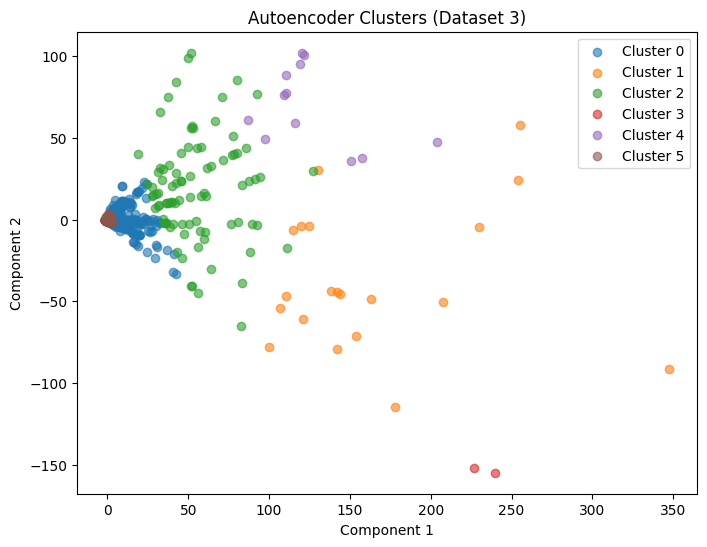

In [104]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(latent_features)

plt.figure(figsize=(8,6))

for c in sorted(d3_wide["cluster"].unique()):
    idx = d3_wide["cluster"] == c
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=f"Cluster {c}", alpha=0.6)

plt.legend()
plt.title("Autoencoder Clusters (Dataset 3)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [105]:
print(d3_wide["cluster"].value_counts())
print("Silhouette:", score)

cluster
5    19998
0     2952
2       90
1       20
4       12
3        2
Name: count, dtype: int64
Silhouette: 0.75298625


Step 10.1 Load Dataset 0

In [106]:
d0 = pd.read_csv("dataset0.txt")

print(d0.shape)
print(d0.columns.tolist())
d0.head()

(30710, 1)
['+----------+------------------+-------------+-------------+----------------+']


,+----------+------------------+-------------+-------------+----------------+
0,| pseudoid | pretreatmenttype | sampleclass | ...
1,+----------+------------------+-------------+-...
2,| 51055 | RAW | C-1 | ...
3,| 52642 | RAW | C-1 | ...
4,| 60026 | RAW | C-1 | ...


In [107]:
import pandas as pd

with open("dataset0.txt", "r", encoding="utf-8") as f:
    lines = f.readlines()

table_lines = [line.strip() for line in lines if line.strip().startswith("|")]

rows = []
for line in table_lines:
    parts = [x.strip() for x in line.strip("|").split("|")]
    rows.append(parts)

df0 = pd.DataFrame(rows[1:], columns=rows[0])
df0.columns = [c.strip().lower() for c in df0.columns]

df0["pseudoid"] = pd.to_numeric(df0["pseudoid"], errors="coerce").astype("Int64")
df0_small = df0[["pseudoid", "sampleclass"]].copy()

print(df0_small.shape)
display(df0_small.head())

(30707, 2)


,pseudoid,sampleclass
0,51055,C-1
1,52642,C-1
2,60026,C-1
3,61469,C-1
4,77085,C-2


In [108]:
df0_small

,pseudoid,sampleclass
0,51055,C-1
1,52642,C-1
2,60026,C-1
3,61469,C-1
4,77085,C-2
...,...,...
30702,50724,C-20
30703,62115,C-1
30704,77495,C-1
30705,59089,C-1


## Step 10.2 Ensure matching ID type

In [109]:
d3_wide["pseudoid"] = pd.to_numeric(d3_wide["pseudoid"], errors="coerce").astype("Int64")

## Step 10.3 Merge clustering result with labels

In [110]:
merged = d3_wide.merge(
    df0_small,
    on="pseudoid",
    how="left"
)

print(merged.shape)
print("Missing sampleclass:", merged["sampleclass"].isna().sum())

(23074, 48)
Missing sampleclass: 0


## Step 10.4 Crosstab (main validation table)

In [111]:
ct = pd.crosstab(merged["cluster"], merged["sampleclass"])
print(ct)

sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              1     7   346     0     0     0    10     0     0     0  ...   
1              0     0     0     0     0     0     0     0     0     0  ...   
2              0     6     0     0     0     0     1     0     0     0  ...   
3              0     1     0     0     0     0     0     0     0     0  ...   
4              0     2     0     0     0     0     0     0     0     0  ...   
5              1  5999   773    93    47   166   141    56    13     8  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0              74    13  1698    84     0   78   17   21   45     0  
1               3     1     9     0     0    2    0    0    0     0  
2              28    16    12     2     0    5    1    1    0     0  
3               1

## Step 10.5 Heatmap visualization

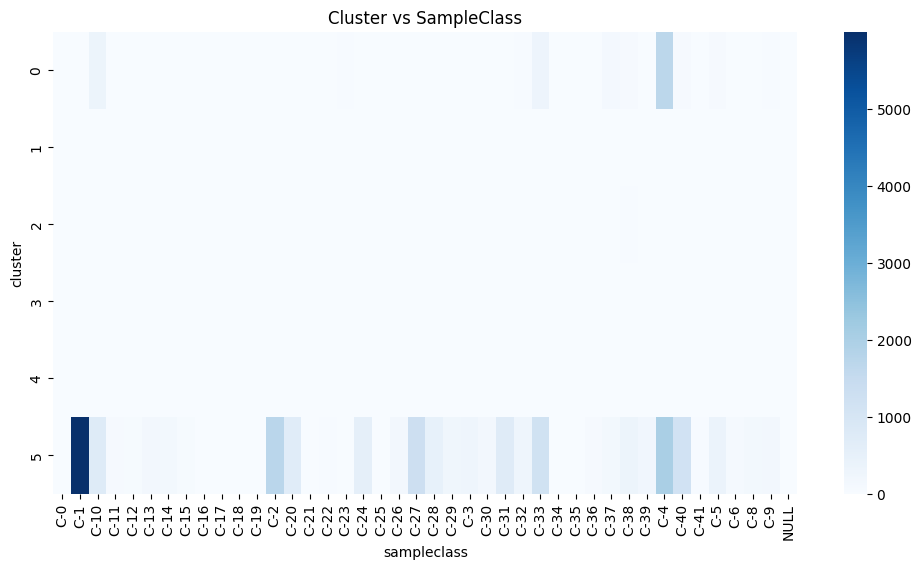

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(ct, cmap="Blues")
plt.title("Cluster vs SampleClass")
plt.show()

In [113]:
valid = merged.dropna(subset=["sampleclass"]).copy()

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(valid["sampleclass"], valid["cluster"])
nmi = normalized_mutual_info_score(valid["sampleclass"], valid["cluster"])

print("ARI:", ari)
print("NMI:", nmi)

ARI: 0.029299558915045543
NMI: 0.09528553113673413


In [114]:
print(ct)
print("ARI:", ari)
print("NMI:", nmi)

sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              1     7   346     0     0     0    10     0     0     0  ...   
1              0     0     0     0     0     0     0     0     0     0  ...   
2              0     6     0     0     0     0     1     0     0     0  ...   
3              0     1     0     0     0     0     0     0     0     0  ...   
4              0     2     0     0     0     0     0     0     0     0  ...   
5              1  5999   773    93    47   166   141    56    13     8  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0              74    13  1698    84     0   78   17   21   45     0  
1               3     1     9     0     0    2    0    0    0     0  
2              28    16    12     2     0    5    1    1    0     0  
3               1

## Step 11: Anomaly Detection (MAIN RESULT)

In [115]:
import numpy as np

recon = autoencoder.predict(X_scaled)
mse = np.mean((X_scaled - recon)**2, axis=1)

threshold = np.percentile(mse, 95)

d3_wide["reconstruction_error"] = mse
d3_wide["anomaly"] = (mse > threshold).astype(int)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 236us/step


In [116]:
d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
1974,52595,243.645569,2.765064,0.0,0.000000,0.000000,1085.391994,3533.824876,0.00000,0.000000,...,1428.57295,418.085929,5474.801737,159.697464,0.0,0.0,0.000000,2,144.032164,1
4228,55625,931.793877,0.000000,0.0,0.000000,0.000000,0.000000,316826.804025,0.00000,0.000000,...,0.00000,379.308973,0.000000,0.000000,0.0,0.0,0.000000,1,130.106279,1
21244,78283,154298.418651,0.000000,0.0,0.000000,0.000000,144415.264923,51716.158291,0.00000,0.000000,...,0.00000,43456.515346,0.000000,0.000000,0.0,0.0,0.000000,1,119.191911,1
5450,57278,3530.113220,0.000000,0.0,0.000000,0.000000,6195.974350,511654.693604,0.00000,0.000000,...,0.00000,1778.463364,0.000000,0.000000,0.0,0.0,0.000000,1,110.079288,1
4809,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,296.002974,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,83.496952,1
13284,67625,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,66.079998,1
20670,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3,50.611464,1
13618,68082,0.000000,0.519190,0.0,31.585117,323.054275,0.000000,0.000000,1.86422,1.670457,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,1.569096,1,48.021245,1
16701,72206,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0,43.985719,1
2239,52948,209.873714,0.000000,0.0,0.000000,0.000000,189.888576,160.608095,0.00000,0.000000,...,0.00000,61.230914,3007.679057,10.158735,0.0,0.0,0.000000,2,43.373090,1


In [117]:
## Anomaly Detection using Autoencoder

In [118]:
### Step 11.1 Reconstruct the data

In [119]:
recon = autoencoder.predict(X_scaled)

722/722 ━━━━━━━━━━━━━━━━━━━━ 0s 241us/step


## Step 11.2 Compute reconstruction error

In [120]:
import numpy as np

mse = np.mean((X_scaled - recon)**2, axis=1)

## Step 11.3 Set anomaly threshold

In [121]:
threshold = np.percentile(mse, 95)
print("Threshold:", threshold)

Threshold: 0.018133596875866576


### Step 11.4 Label anomalies

In [122]:
d3_wide["reconstruction_error"] = mse
d3_wide["anomaly"] = (mse > threshold).astype(int)

Step 11.5 Check how many anomalies

In [123]:
print(d3_wide["anomaly"].value_counts())

anomaly
0    21921
1     1153
Name: count, dtype: int64


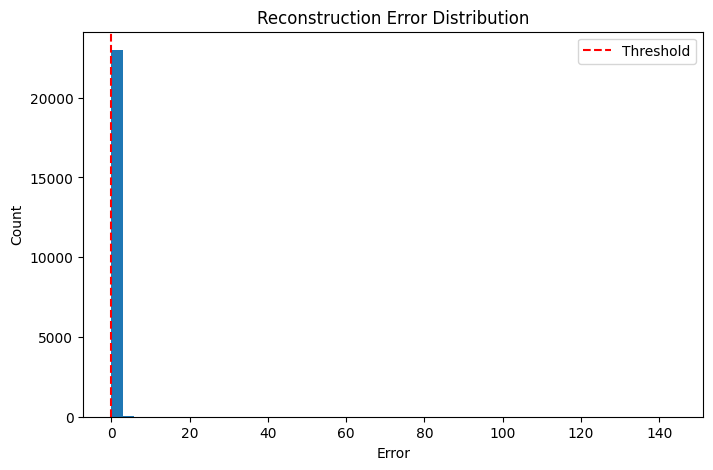

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(mse, bins=50)
plt.axvline(threshold, color="red", linestyle="--", label="Threshold")
plt.title("Reconstruction Error Distribution")
plt.xlabel("Error")
plt.ylabel("Count")
plt.legend()
plt.show()

Step 11.7 See top anomalies

In [125]:
top_anomalies = d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

display(top_anomalies)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
1974,52595,243.645569,2.765064,0.0,0.000000,0.000000,1085.391994,3533.824876,0.00000,0.000000,...,1428.57295,418.085929,5474.801737,159.697464,0.0,0.0,0.000000,2,144.032164,1
4228,55625,931.793877,0.000000,0.0,0.000000,0.000000,0.000000,316826.804025,0.00000,0.000000,...,0.00000,379.308973,0.000000,0.000000,0.0,0.0,0.000000,1,130.106279,1
21244,78283,154298.418651,0.000000,0.0,0.000000,0.000000,144415.264923,51716.158291,0.00000,0.000000,...,0.00000,43456.515346,0.000000,0.000000,0.0,0.0,0.000000,1,119.191911,1
5450,57278,3530.113220,0.000000,0.0,0.000000,0.000000,6195.974350,511654.693604,0.00000,0.000000,...,0.00000,1778.463364,0.000000,0.000000,0.0,0.0,0.000000,1,110.079288,1
4809,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,296.002974,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,83.496952,1
13284,67625,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,66.079998,1
20670,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3,50.611464,1
13618,68082,0.000000,0.519190,0.0,31.585117,323.054275,0.000000,0.000000,1.86422,1.670457,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,1.569096,1,48.021245,1
16701,72206,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0,43.985719,1
2239,52948,209.873714,0.000000,0.0,0.000000,0.000000,189.888576,160.608095,0.00000,0.000000,...,0.00000,61.230914,3007.679057,10.158735,0.0,0.0,0.000000,2,43.373090,1


In [126]:
print(d3_wide["anomaly"].value_counts())
print(threshold)
display(top_anomalies)

anomaly
0    21921
1     1153
Name: count, dtype: int64
0.018133596875866576


nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
1974,52595,243.645569,2.765064,0.0,0.000000,0.000000,1085.391994,3533.824876,0.00000,0.000000,...,1428.57295,418.085929,5474.801737,159.697464,0.0,0.0,0.000000,2,144.032164,1
4228,55625,931.793877,0.000000,0.0,0.000000,0.000000,0.000000,316826.804025,0.00000,0.000000,...,0.00000,379.308973,0.000000,0.000000,0.0,0.0,0.000000,1,130.106279,1
21244,78283,154298.418651,0.000000,0.0,0.000000,0.000000,144415.264923,51716.158291,0.00000,0.000000,...,0.00000,43456.515346,0.000000,0.000000,0.0,0.0,0.000000,1,119.191911,1
5450,57278,3530.113220,0.000000,0.0,0.000000,0.000000,6195.974350,511654.693604,0.00000,0.000000,...,0.00000,1778.463364,0.000000,0.000000,0.0,0.0,0.000000,1,110.079288,1
4809,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,296.002974,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,83.496952,1
13284,67625,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,66.079998,1
20670,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3,50.611464,1
13618,68082,0.000000,0.519190,0.0,31.585117,323.054275,0.000000,0.000000,1.86422,1.670457,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,1.569096,1,48.021245,1
16701,72206,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0,43.985719,1
2239,52948,209.873714,0.000000,0.0,0.000000,0.000000,189.888576,160.608095,0.00000,0.000000,...,0.00000,61.230914,3007.679057,10.158735,0.0,0.0,0.000000,2,43.373090,1


In [127]:
top_anomalies = d3_wide.sort_values("reconstruction_error", ascending=False).head(10)

display(top_anomalies)

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TH-234,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly
1974,52595,243.645569,2.765064,0.0,0.000000,0.000000,1085.391994,3533.824876,0.00000,0.000000,...,1428.57295,418.085929,5474.801737,159.697464,0.0,0.0,0.000000,2,144.032164,1
4228,55625,931.793877,0.000000,0.0,0.000000,0.000000,0.000000,316826.804025,0.00000,0.000000,...,0.00000,379.308973,0.000000,0.000000,0.0,0.0,0.000000,1,130.106279,1
21244,78283,154298.418651,0.000000,0.0,0.000000,0.000000,144415.264923,51716.158291,0.00000,0.000000,...,0.00000,43456.515346,0.000000,0.000000,0.0,0.0,0.000000,1,119.191911,1
5450,57278,3530.113220,0.000000,0.0,0.000000,0.000000,6195.974350,511654.693604,0.00000,0.000000,...,0.00000,1778.463364,0.000000,0.000000,0.0,0.0,0.000000,1,110.079288,1
4809,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,296.002974,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,83.496952,1
13284,67625,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,66.079998,1
20670,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3,50.611464,1
13618,68082,0.000000,0.519190,0.0,31.585117,323.054275,0.000000,0.000000,1.86422,1.670457,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,1.569096,1,48.021245,1
16701,72206,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.00000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0,43.985719,1
2239,52948,209.873714,0.000000,0.0,0.000000,0.000000,189.888576,160.608095,0.00000,0.000000,...,0.00000,61.230914,3007.679057,10.158735,0.0,0.0,0.000000,2,43.373090,1


In [128]:
import pandas as pd
import numpy as np

percentiles = list(range(90, 101))

threshold_table = pd.DataFrame({
    "percentile": percentiles,
    "threshold": [np.percentile(mse, p) for p in percentiles],
    "num_anomalies": [(mse > np.percentile(mse, p)).sum() for p in percentiles],
})

threshold_table["percent_anomalies"] = (
    threshold_table["num_anomalies"] / len(mse) * 100
)

display(threshold_table)

,percentile,threshold,num_anomalies,percent_anomalies
0,90,0.004921,2308,10.002600
1,91,0.005888,2077,9.001474
2,92,0.007245,1846,8.000347
3,93,0.009624,1616,7.003554
4,94,0.012898,1385,6.002427
5,95,0.018134,1153,4.996966
6,96,0.026536,923,4.000173
7,97,0.039242,693,3.003380
8,98,0.069431,462,2.002254
9,99,0.292562,231,1.001127


In [129]:
threshold_table["gap"] = threshold_table["threshold"].diff()

display(threshold_table)

,percentile,threshold,num_anomalies,percent_anomalies,gap
0,90,0.004921,2308,10.002600,NaN
1,91,0.005888,2077,9.001474,0.000967
2,92,0.007245,1846,8.000347,0.001357
3,93,0.009624,1616,7.003554,0.002380
4,94,0.012898,1385,6.002427,0.003273
5,95,0.018134,1153,4.996966,0.005236
6,96,0.026536,923,4.000173,0.008403
7,97,0.039242,693,3.003380,0.012705
8,98,0.069431,462,2.002254,0.030189
9,99,0.292562,231,1.001127,0.223131


## Threshold 99 

In [130]:
threshold_99 = np.percentile(mse, 99)

print("Threshold (99%):", threshold_99)

Threshold (99%): 0.2925623316498767


In [131]:
d3_wide["anomaly_99"] = (mse > threshold_99).astype(int)

print(d3_wide["anomaly_99"].value_counts())

anomaly_99
0    22843
1      231
Name: count, dtype: int64


In [132]:
top_anomalies_99 = d3_wide[d3_wide["anomaly_99"] == 1] \
    .sort_values("reconstruction_error", ascending=False)

display(top_anomalies_99.head(10))

nuclide_clean,pseudoid,AC-228,AG-110M,AM-241,BA-140,BE-7,BI-212,BI-214,CE-141,CE-144,...,TL-208,Th-232,U-235,U-238,VIITTEELLINEN ANNOS,ZR-95,cluster,reconstruction_error,anomaly,anomaly_99
1974,52595,243.645569,2.765064,0.0,0.000000,0.000000,1085.391994,3533.824876,0.00000,0.000000,...,418.085929,5474.801737,159.697464,0.0,0.0,0.000000,2,144.032164,1,1
4228,55625,931.793877,0.000000,0.0,0.000000,0.000000,0.000000,316826.804025,0.00000,0.000000,...,379.308973,0.000000,0.000000,0.0,0.0,0.000000,1,130.106279,1,1
21244,78283,154298.418651,0.000000,0.0,0.000000,0.000000,144415.264923,51716.158291,0.00000,0.000000,...,43456.515346,0.000000,0.000000,0.0,0.0,0.000000,1,119.191911,1,1
5450,57278,3530.113220,0.000000,0.0,0.000000,0.000000,6195.974350,511654.693604,0.00000,0.000000,...,1778.463364,0.000000,0.000000,0.0,0.0,0.000000,1,110.079288,1,1
4809,56404,0.000000,115.158149,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,296.002974,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,83.496952,1,1
13284,67625,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,1,66.079998,1,1
20670,77523,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,3,50.611464,1,1
13618,68082,0.000000,0.519190,0.0,31.585117,323.054275,0.000000,0.000000,1.86422,1.670457,...,0.000000,0.000000,0.000000,0.0,0.0,1.569096,1,48.021245,1,1
16701,72206,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0,43.985719,1,1
2239,52948,209.873714,0.000000,0.0,0.000000,0.000000,189.888576,160.608095,0.00000,0.000000,...,61.230914,3007.679057,10.158735,0.0,0.0,0.000000,2,43.373090,1,1


In [133]:
threshold_99 = np.percentile(mse, 99)

d3_wide["reconstruction_error"] = mse
d3_wide["anomaly_99"] = (mse > threshold_99).astype(int)

anomaly_ids_99 = d3_wide.loc[d3_wide["anomaly_99"] == 1, "pseudoid"]

print("Number of 99% anomalies:", len(anomaly_ids_99))
display(anomaly_ids_99.head(10))

Number of 99% anomalies: 231


27     50040
141    50191
308    50405
455    50591
466    50606
515    50671
594    50787
632    50837
652    50859
705    50927
Name: pseudoid, dtype: Int64

In [134]:
d3_model_rows = d3_model.copy()
d3_model_rows = d3_model_rows.reset_index().rename(columns={"index": "d3_row_number"})

In [135]:
anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(anomaly_ids_99)].copy()

print("Number of Dataset 3 rows belonging to 99% anomaly pseudoids:", len(anomaly_rows_99))

display(
    anomaly_rows_99[
        ["d3_row_number", "pseudoid", "nuclide_clean", "result_raw", "result", "unit_std", "uncertainty", "is_mda"]
    ].head(50)
)

Number of Dataset 3 rows belonging to 99% anomaly pseudoids: 2390


,d3_row_number,pseudoid,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda
99,103,50040,K-40,1581.7642211914062,1.581764e+03,Bq/m3,7.3,False
100,104,50040,SB-125,814.915161475965,8.149152e+02,Bq/m3,2.1,False
101,105,50040,CS-137,543.0945191048654,5.430945e+02,Bq/m3,5.1,False
102,106,50040,CO-60,252.23566117750136,2.522357e+02,Bq/m3,3.4,False
103,107,50040,AG-110M,218.25780796949903,2.182578e+02,Bq/m3,1.7,False
104,108,50040,CS-134,14.903089887321519,1.490309e+01,Bq/m3,4.4,False
105,109,50040,AG-108M,5.666937873351122,5.666938e+00,Bq/m3,7.4,False
106,110,50040,CO-58,6.7666325345226515,6.766633e+00,Bq/m3,11.0,False
107,111,50040,MN-54,5.308912236267827,5.308912e+00,Bq/m3,11.0,False
108,112,50040,SB-124,5.650301105862477,5.650301e+00,Bq/m3,11.0,False


In [136]:
anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(anomaly_ids_99)].copy()

print("Number of Dataset 3 rows belonging to 99% anomaly pseudoids:", len(anomaly_rows_99))

display(
    anomaly_rows_99[
        ["d3_row_number", "pseudoid", "nuclide_clean", "result_raw", "result", "unit_std", "uncertainty", "is_mda"]
    ]
)

Number of Dataset 3 rows belonging to 99% anomaly pseudoids: 2390


,d3_row_number,pseudoid,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda
99,103,50040,K-40,1581.7642211914062,1581.764221,Bq/m3,7.3,False
100,104,50040,SB-125,814.915161475965,814.915161,Bq/m3,2.1,False
101,105,50040,CS-137,543.0945191048654,543.094519,Bq/m3,5.1,False
102,106,50040,CO-60,252.23566117750136,252.235661,Bq/m3,3.4,False
103,107,50040,AG-110M,218.25780796949903,218.257808,Bq/m3,1.7,False
...,...,...,...,...,...,...,...,...
97334,97944,80704,CS-137,1882.5662251551748,1882.566225,Bq/l,3.6,False
97335,97945,80704,SN-113,2001.8512071582063,2001.851207,Bq/l,4.0,False
97336,97946,80704,RA-226,1080.4125785827637,1080.412579,Bq/l,6.6,False
97337,97947,80704,CO-57,417.18463597686394,417.184636,Bq/l,3.8,False


In [137]:
print("Anomalous samples:", len(anomaly_ids_99))
print("Rows belonging to those samples:", len(anomaly_rows_99))

Anomalous samples: 231
Rows belonging to those samples: 2390


Step 12.1 Create interpretable features

In [138]:
res_cols = [c for c in d3_wide.columns 
            if c not in ["pseudoid", "cluster", "reconstruction_error", "anomaly_99"]]

d3_wide["total_activity"] = d3_wide[res_cols].sum(axis=1)
d3_wide["num_nuclides"] = (d3_wide[res_cols] > 0).sum(axis=1)
d3_wide["max_activity"] = d3_wide[res_cols].max(axis=1)

Step 12.2 Compare normal vs anomalies

In [139]:
d3_wide.groupby("anomaly_99")[["total_activity", "num_nuclides", "max_activity"]].mean()

nuclide_clean,total_activity,num_nuclides,max_activity
anomaly_99,,,
0,2.479003e+28,4.02990,1.828815e+28
1,2.558447e+50,8.82684,2.558447e+50


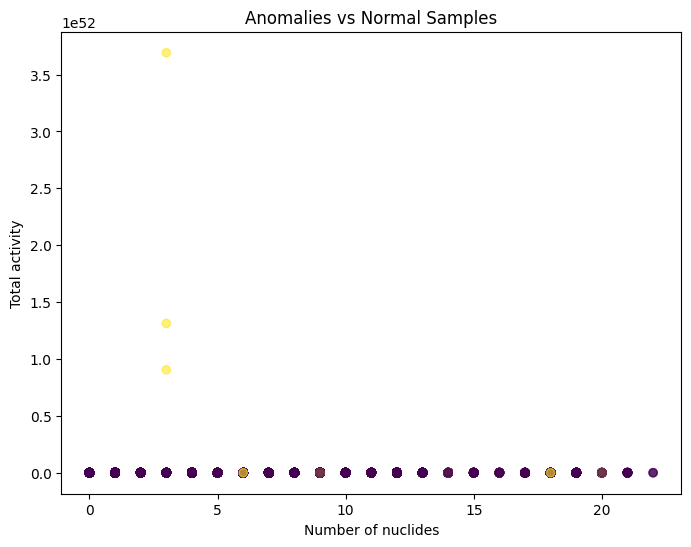

In [140]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    d3_wide["num_nuclides"],
    d3_wide["total_activity"],
    c=d3_wide["anomaly_99"],
    alpha=0.6
)

plt.xlabel("Number of nuclides")
plt.ylabel("Total activity")
plt.title("Anomalies vs Normal Samples")

plt.show()

In [141]:
t90 = np.percentile(mse, 90)
t99 = np.percentile(mse, 99)

def classify(x):
    if x <= t90:
        return "Typical"
    elif x <= t99:
        return "Atypical"
    else:
        return "Erroneous"

d3_wide["final_class"] = [classify(x) for x in mse]

In [142]:
print(d3_wide["final_class"].value_counts())

final_class
Typical      20766
Atypical      2077
Erroneous      231
Name: count, dtype: int64


In [143]:
final_output = d3_wide[[
    "pseudoid",
    "final_class",
    "reconstruction_error",
    "total_activity",
    "num_nuclides",
    "max_activity"
]]

display(final_output.head())

nuclide_clean,pseudoid,final_class,reconstruction_error,total_activity,num_nuclides,max_activity
0,50001,Typical,0.001945,1312.371265,5,1121.566455
1,50002,Typical,0.000997,0.104467,2,0.079320
2,50003,Typical,0.000461,115.446577,2,106.960499
3,50004,Typical,0.000132,3.115184,3,3.090339
4,50005,Typical,0.000132,0.000041,1,0.000041


In [144]:
print("=== Clustering Results ===")
print(d3_wide["cluster"].value_counts())

from sklearn.metrics import silhouette_score
print("\nSilhouette Score:", silhouette_score(latent_features, d3_wide["cluster"]))

=== Clustering Results ===
cluster
5    19998
0     2952
2       90
1       20
4       12
3        2
Name: count, dtype: int64

Silhouette Score: 0.75298625


In [145]:
print("\n=== Validation Results ===")

print("\nCluster vs SampleClass:")
print(ct)

print("\nARI:", ari)
print("NMI:", nmi)


=== Validation Results ===

Cluster vs SampleClass:
sampleclass  C-0   C-1  C-10  C-11  C-12  C-13  C-14  C-15  C-16  C-17  ...  \
cluster                                                                 ...   
0              1     7   346     0     0     0    10     0     0     0  ...   
1              0     0     0     0     0     0     0     0     0     0  ...   
2              0     6     0     0     0     0     1     0     0     0  ...   
3              0     1     0     0     0     0     0     0     0     0  ...   
4              0     2     0     0     0     0     0     0     0     0  ...   
5              1  5999   773    93    47   166   141    56    13     8  ...   

sampleclass  C-38  C-39   C-4  C-40  C-41  C-5  C-6  C-8  C-9  NULL  
cluster                                                              
0              74    13  1698    84     0   78   17   21   45     0  
1               3     1     9     0     0    2    0    0    0     0  
2              28    16    12     

In [146]:
print("\n=== Threshold Analysis ===")
display(threshold_table)


=== Threshold Analysis ===


,percentile,threshold,num_anomalies,percent_anomalies,gap
0,90,0.004921,2308,10.002600,NaN
1,91,0.005888,2077,9.001474,0.000967
2,92,0.007245,1846,8.000347,0.001357
3,93,0.009624,1616,7.003554,0.002380
4,94,0.012898,1385,6.002427,0.003273
5,95,0.018134,1153,4.996966,0.005236
6,96,0.026536,923,4.000173,0.008403
7,97,0.039242,693,3.003380,0.012705
8,98,0.069431,462,2.002254,0.030189
9,99,0.292562,231,1.001127,0.223131


In [147]:
print("\n=== Anomaly Detection (99%) ===")

print("Threshold (99%):", threshold_99)
print(d3_wide["anomaly_99"].value_counts())


=== Anomaly Detection (99%) ===
Threshold (99%): 0.2925623316498767
anomaly_99
0    22843
1      231
Name: count, dtype: int64


In [148]:
print("\n=== Final Classification ===")

print(d3_wide["final_class"].value_counts())


=== Final Classification ===
final_class
Typical      20766
Atypical      2077
Erroneous      231
Name: count, dtype: int64


In [149]:
anomaly_ids_99

27       50040
141      50191
308      50405
455      50591
466      50606
         ...  
22725    80239
23013    80624
23028    80643
23044    80670
23070    80704
Name: pseudoid, Length: 231, dtype: Int64

In [150]:
anomaly_rows_99.to_csv("dataset3_anomalies_99.csv", index=False)

In [151]:
anomaly_ids_99.to_csv("anomaly_ids_99.csv", index=False)

In [152]:
training_errors = mse.copy()
threshold_99 = np.percentile(mse, 99)
feature_cols = X.columns.tolist()

In [153]:
import pandas as pd
import numpy as np

def prepare_new_sample_data(new_d3_cleaned, feature_cols):
    new_model = new_d3_cleaned[
        (~new_d3_cleaned["is_mass_concentration"]) &
        (~new_d3_cleaned["is_pu239_240"])
    ].copy()

    new_wide = new_model.pivot_table(
        index="pseudoid",
        columns="nuclide_clean",
        values="result",
        aggfunc="mean"
    ).fillna(0)

    new_wide.reset_index(inplace=True)

    for col in feature_cols:
        if col not in new_wide.columns:
            new_wide[col] = 0

    new_wide = new_wide[["pseudoid"] + feature_cols]

    return new_wide

In [159]:
def score_new_data(new_wide, scaler, autoencoder, training_errors, threshold_99):
    X_new = new_wide.drop(columns=["pseudoid"])
    X_new_scaled = scaler.transform(X_new)

    recon_new = autoencoder.predict(X_new_scaled, verbose=0)
    mse_new = np.mean((X_new_scaled - recon_new) ** 2, axis=1)

    anomaly_flag = (mse_new > threshold_99).astype(int)

    anomaly_percentile = [
        100 * (training_errors <= err).mean()
        for err in mse_new
    ]

    def classify(p):
        if p <= 90:
            return "Typical"
        elif p <= 99:
            return "Atypical"
        else:
            return "Erroneous"

    result = new_wide[["pseudoid"]].copy()
    result["reconstruction_error"] = mse_new
    result["threshold_99"] = threshold_99
    result["is_anomaly_99"] = anomaly_flag
    result["anomaly_percentile"] = anomaly_percentile
    result["final_class"] = result["anomaly_percentile"].apply(classify)

    return result

In [160]:
new_d3 = pd.read_csv("dataset3_cleaned.csv")

new_wide = prepare_new_sample_data(new_d3, feature_cols)
new_scores = score_new_data(
    new_wide=new_wide,
    scaler=scaler,
    autoencoder=autoencoder,
    training_errors=training_errors,
    threshold_99=threshold_99
)

display(new_scores.head(20))

nuclide_clean,pseudoid,reconstruction_error,threshold_99,is_anomaly_99,anomaly_percentile,final_class
0,50001,0.001945,0.292562,0,80.406518,Typical
1,50002,0.000997,0.292562,0,68.202306,Typical
2,50003,0.000461,0.292562,0,62.104533,Typical
3,50004,0.000132,0.292562,0,46.398544,Typical
4,50005,0.000132,0.292562,0,27.827858,Typical
5,50006,0.001060,0.292562,0,69.974863,Typical
6,50007,0.000132,0.292562,0,15.246598,Typical
7,50008,0.001588,0.292562,0,78.469273,Typical
8,50009,0.000132,0.292562,0,4.576580,Typical
9,50010,0.001010,0.292562,0,68.557684,Typical


In [163]:
d3_wide["anomaly_percentage"] = [
    100 * (mse <= err).mean()
    for err in mse
]

display(
    d3_wide[
        ["pseudoid","reconstruction_error","anomaly_percentage"]
    ].head(20)
)

nuclide_clean,pseudoid,reconstruction_error,anomaly_percentage
0,50001,0.001945,80.406518
1,50002,0.000997,68.202306
2,50003,0.000461,62.104533
3,50004,0.000132,46.398544
4,50005,0.000132,27.827858
5,50006,0.001060,69.974863
6,50007,0.000132,15.246598
7,50008,0.001588,78.469273
8,50009,0.000132,4.576580
9,50010,0.001010,68.557684


In [164]:
display(
    d3_wide[d3_wide["anomaly_99"]==1][
        ["pseudoid","reconstruction_error","anomaly_percentage"]
    ].head(20)
)

nuclide_clean,pseudoid,reconstruction_error,anomaly_percentage
27,50040,5.090663,99.748635
141,50191,3.308692,99.640288
308,50405,0.457994,99.241571
455,50591,0.394622,99.163561
466,50606,2.356210,99.588281
515,50671,0.296157,99.011875
594,50787,25.823159,99.913322
632,50837,2.090867,99.570946
652,50859,1.570976,99.536275
705,50927,1.380669,99.518939


In [165]:
anomalies_99 = d3_wide[d3_wide["anomaly_99"] == 1].copy()
non_anomalies_99 = d3_wide[d3_wide["anomaly_99"] == 0].copy()

print("Anomalies shape:", anomalies_99.shape)
print("Non anomalies shape:", non_anomalies_99.shape)

Anomalies shape: (231, 55)
Non anomalies shape: (22843, 55)


In [166]:
anomalies_99.to_csv("anomalies_99.csv", index=False)
non_anomalies_99.to_csv("non_anomalies_99.csv", index=False)

In [167]:
import numpy as np

threshold_99 = np.percentile(mse, 99)

d3_wide["reconstruction_error"] = mse
d3_wide["anomaly_99"] = (mse > threshold_99).astype(int)

anomaly_ids_99 = d3_wide.loc[d3_wide["anomaly_99"] == 1, "pseudoid"].drop_duplicates()

print("Number of 99% anomalies:", len(anomaly_ids_99))
display(anomaly_ids_99.head(10))

Number of 99% anomalies: 231


27     50040
141    50191
308    50405
455    50591
466    50606
515    50671
594    50787
632    50837
652    50859
705    50927
Name: pseudoid, dtype: Int64

In [168]:
d3_model_rows = d3_model.copy()
d3_model_rows = d3_model_rows.reset_index().rename(columns={"index": "d3_row_number"})

anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(anomaly_ids_99)].copy()

print("Number of Dataset 3 rows belonging to 99% anomaly pseudoids:", len(anomaly_rows_99))

display(
    anomaly_rows_99[
        ["d3_row_number", "pseudoid", "nuclide_clean", "result_raw", "result", "unit_std", "uncertainty", "is_mda"]
    ].head(50)
)

print("Anomalous samples:", len(anomaly_ids_99))
print("Rows belonging to those samples:", len(anomaly_rows_99))

Number of Dataset 3 rows belonging to 99% anomaly pseudoids: 2390


,d3_row_number,pseudoid,nuclide_clean,result_raw,result,unit_std,uncertainty,is_mda
99,103,50040,K-40,1581.7642211914062,1.581764e+03,Bq/m3,7.3,False
100,104,50040,SB-125,814.915161475965,8.149152e+02,Bq/m3,2.1,False
101,105,50040,CS-137,543.0945191048654,5.430945e+02,Bq/m3,5.1,False
102,106,50040,CO-60,252.23566117750136,2.522357e+02,Bq/m3,3.4,False
103,107,50040,AG-110M,218.25780796949903,2.182578e+02,Bq/m3,1.7,False
104,108,50040,CS-134,14.903089887321519,1.490309e+01,Bq/m3,4.4,False
105,109,50040,AG-108M,5.666937873351122,5.666938e+00,Bq/m3,7.4,False
106,110,50040,CO-58,6.7666325345226515,6.766633e+00,Bq/m3,11.0,False
107,111,50040,MN-54,5.308912236267827,5.308912e+00,Bq/m3,11.0,False
108,112,50040,SB-124,5.650301105862477,5.650301e+00,Bq/m3,11.0,False


Anomalous samples: 231
Rows belonging to those samples: 2390


In [169]:
non_anomaly_ids_99 = d3_wide.loc[d3_wide["anomaly_99"] == 0, "pseudoid"].drop_duplicates()

non_anomaly_rows_99 = d3_model_rows[d3_model_rows["pseudoid"].isin(non_anomaly_ids_99)].copy()

print("Non-anomalous samples:", len(non_anomaly_ids_99))
print("Rows belonging to non-anomalous samples:", len(non_anomaly_rows_99))

Non-anomalous samples: 22843
Rows belonging to non-anomalous samples: 94955


In [170]:
anomaly_rows_99.to_csv("dataset3_anomaly_rows_99.csv", index=False)
non_anomaly_rows_99.to_csv("dataset3_non_anomaly_rows_99.csv", index=False)

anomaly_ids_99.rename("pseudoid").to_csv("dataset3_anomaly_ids_99.csv", index=False)
non_anomaly_ids_99.rename("pseudoid").to_csv("dataset3_non_anomaly_ids_99.csv", index=False)

[[22843     0]
 [    0   231]]


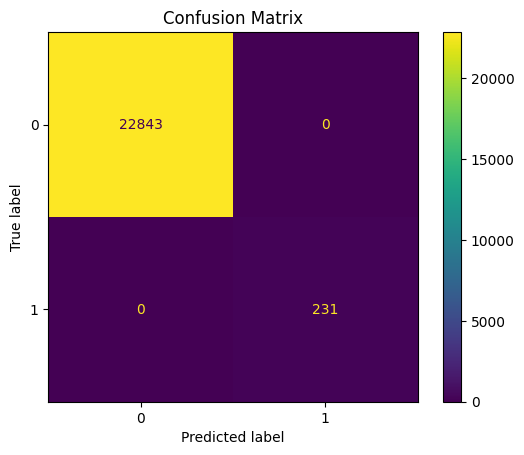

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     22843
           1       1.00      1.00      1.00       231

    accuracy                           1.00     23074
   macro avg       1.00      1.00      1.00     23074
weighted avg       1.00      1.00      1.00     23074



In [171]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import pandas as pd
import matplotlib.pyplot as plt

anom_loaded = pd.read_csv("dataset3_anomaly_ids_99.csv")
non_anom_loaded = pd.read_csv("dataset3_non_anomaly_ids_99.csv")

anom_loaded["true_label"] = 1
non_anom_loaded["true_label"] = 0

combined_ids = pd.concat([anom_loaded, non_anom_loaded], ignore_index=True)

pred_df = d3_wide[["pseudoid", "anomaly_99"]].copy()
pred_df["pseudoid"] = pd.to_numeric(pred_df["pseudoid"], errors="coerce")
combined_ids["pseudoid"] = pd.to_numeric(combined_ids["pseudoid"], errors="coerce")

eval_df = combined_ids.merge(pred_df, on="pseudoid", how="left")

y_true = eval_df["true_label"]
y_pred = eval_df["anomaly_99"]

cm = confusion_matrix(y_true, y_pred)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot()
plt.title("Confusion Matrix")
plt.show()

print(classification_report(y_true, y_pred))